Para efeito de benchmark nacional, optou-se por construir os indicadores a partir da agregação direta das carteiras de todos os estados, de modo que os percentuais reflitam a estrutura e o risco efetivos do sistema de crédito nacional, e não a média simples entre unidades federativas.

A análise considera uma série temporal contínua abrangendo os anos de 2024 e 2025, permitindo avaliar a evolução recente dos indicadores de risco. Sempre que pertinente, são destacadas diferenças médias entre os anos, sem assumir estabilidade estrutural do período.

In [1]:
import pandas as pd

In [3]:
import pandas as pd
import glob

# Listar todos os arquivos CSV do SCR
arquivos = glob.glob("scrdata_*.csv")

# Ler todos os arquivos
dfs = [
    pd.read_csv(arq, sep=";")
    for arq in arquivos
]

# Unir tudo em um único DataFrame
df_raw = pd.concat(dfs, ignore_index=True)

df_raw.shape


(6681343, 24)

Primeira fase, após a limpeza dos dados, que no caso, já vieram estruturados, é garantir a tipagem dos dados. Nessa fase vamos definir o tipo dos valores, se float, int, datatime, string, etc.
Isso garante que a análise seja feita de forma correta, pois cada valor obdece a sua natureza. 

In [4]:
# Converter data_base para datetime
df_raw['data_base'] = pd.to_datetime(df_raw['data_base'])

# Verificar intervalo temporal
df_raw['data_base'].min(), df_raw['data_base'].max()


(Timestamp('2024-01-31 00:00:00'), Timestamp('2025-10-31 00:00:00'))

In [28]:
# Colunas métricas
cols_metricas = [
    'carteira_ativa',
    'carteira_inadimplencia',
    'ativo_problematico'
]

# Converter métricas NO DF RAW (ANTES de qualquer groupby)
for col in cols_metricas:
    df_raw[col] = (
        df_raw[col]
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

df_raw[cols_metricas].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6681343 entries, 0 to 6681342
Data columns (total 3 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   carteira_ativa          float64
 1   carteira_inadimplencia  float64
 2   ativo_problematico      float64
dtypes: float64(3)
memory usage: 152.9 MB


Ao se trabalhar com base de dados grandes, é preciso otimizar os processos, para garantir velocidade e economia.
Como a base é composta de seis (6681343) milhões de linhas, convém selecionarmos somente os dados necessários para nossa análise.

In [ ]:
# Selecionar apenas colunas necessárias
cols = [
    'data_base',
    'uf',
    'carteira_ativa',
    'carteira_inadimplencia',
    'ativo_problematico'
]

df_tmp = df_raw[cols]

# Agregação mensal por UF
mensal_uf = (df_tmp.groupby(['data_base', 'uf'], as_index=False).sum())

mensal_uf.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   data_base               594 non-null    datetime64[ns]
 1   uf                      594 non-null    object        
 2   carteira_ativa          594 non-null    float64       
 3   carteira_inadimplencia  594 non-null    float64       
 4   ativo_problematico      594 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 23.3+ KB


In [30]:
mensal_uf.head()

,data_base,uf,carteira_ativa,carteira_inadimplencia,ativo_problematico
0,2024-01-31,AC,1.503081e+10,5.536563e+08,1.013230e+09
1,2024-01-31,AL,4.518153e+10,1.915634e+09,3.687406e+09
2,2024-01-31,AM,5.756344e+10,2.503561e+09,4.736760e+09
3,2024-01-31,AP,1.439639e+10,5.529521e+08,1.101487e+09
4,2024-01-31,BA,2.223853e+11,9.309907e+09,1.767383e+10


Nessa parte agregamos os dados somente pelo estado do RS e os demais estados brasileiros criando a região BR.
Já que nosso objetivo é comparar o estado do RS com o resto das federações.

In [32]:
rs_mensal = mensal_uf[mensal_uf['uf'] == 'RS'].copy()
rs_mensal['regiao'] = 'RS'

In [33]:
rs_mensal.head()

,data_base,uf,carteira_ativa,carteira_inadimplencia,ativo_problematico,regiao
22,2024-01-31,RS,4.101343e+11,1.045254e+10,2.550481e+10,RS
49,2024-02-29,RS,4.120652e+11,1.075185e+10,2.582071e+10,RS
76,2024-03-31,RS,4.186817e+11,1.105926e+10,2.619277e+10,RS
103,2024-04-30,RS,4.219996e+11,1.107354e+10,2.620452e+10,RS
130,2024-05-31,RS,4.212094e+11,1.151733e+10,2.655295e+10,RS


In [34]:
# --- Brasil (agregado nacional) ---
br_mensal = (mensal_uf.groupby('data_base', as_index=False)[['carteira_ativa', 'carteira_inadimplencia', 'ativo_problematico']].sum())
br_mensal['regiao'] = 'BR'

In [35]:
br_mensal.head()

,data_base,carteira_ativa,carteira_inadimplencia,ativo_problematico,regiao
0,2024-01-31,5.961109e+12,1.897955e+11,4.319570e+11,BR
1,2024-02-29,5.976827e+12,1.906889e+11,4.335469e+11,BR
2,2024-03-31,6.062302e+12,1.905498e+11,4.331606e+11,BR
3,2024-04-30,6.090115e+12,1.929457e+11,4.394963e+11,BR
4,2024-05-31,6.132263e+12,1.977540e+11,4.412117e+11,BR


In [36]:
# --- Unir ---
base_mensal = pd.concat([rs_mensal, br_mensal], ignore_index=True)
base_mensal = base_mensal.sort_values(['regiao', 'data_base'])

In [37]:
base_mensal.head()

,data_base,uf,carteira_ativa,carteira_inadimplencia,ativo_problematico,regiao
22,2024-01-31,NaN,5.961109e+12,1.897955e+11,4.319570e+11,BR
23,2024-02-29,NaN,5.976827e+12,1.906889e+11,4.335469e+11,BR
24,2024-03-31,NaN,6.062302e+12,1.905498e+11,4.331606e+11,BR
25,2024-04-30,NaN,6.090115e+12,1.929457e+11,4.394963e+11,BR
26,2024-05-31,NaN,6.132263e+12,1.977540e+11,4.412117e+11,BR


Concluímos as conversões de tipo e os agrupamentos necessários. Cada linha do dataframe representa o somatório mensal das variáveis financeiras, agregadas por região (RS e Brasil), resultando em uma série temporal com 22 meses — de janeiro de 2024 a outubro de 2025 — e duas observações por mês.<br>

A partir dessa etapa, dispomos do valor da carteira ativa, da inadimplência e do ativo problemático para cada mês, tanto para o Estado do Rio Grande do Sul quanto para o agregado nacional, que será utilizado como benchmark.

In [47]:
# Percentual de inadimplência
base_mensal['pct_inadimplencia'] = round((base_mensal['carteira_inadimplencia'] / base_mensal['carteira_ativa']) * 100, 2)

# Percentual de ativo problemático
base_mensal['pct_ativo_problematico'] = round((base_mensal['ativo_problematico'] / base_mensal['carteira_ativa']) * 100, 2)

base_mensal[['data_base', 'regiao', 'pct_inadimplencia', 'pct_ativo_problematico']].head()


,data_base,regiao,pct_inadimplencia,pct_ativo_problematico
22,2024-01-31,BR,3.18,7.25
23,2024-02-29,BR,3.19,7.25
24,2024-03-31,BR,3.14,7.15
25,2024-04-30,BR,3.17,7.22
26,2024-05-31,BR,3.22,7.19


In [57]:
base_mensal.head()

,data_base,uf,carteira_ativa,carteira_inadimplencia,ativo_problematico,regiao,pct_inadimplencia,pct_ativo_problematico
22,2024-01-31,NaN,5.961109e+12,1.897955e+11,4.319570e+11,BR,3.18,7.25
23,2024-02-29,NaN,5.976827e+12,1.906889e+11,4.335469e+11,BR,3.19,7.25
24,2024-03-31,NaN,6.062302e+12,1.905498e+11,4.331606e+11,BR,3.14,7.15
25,2024-04-30,NaN,6.090115e+12,1.929457e+11,4.394963e+11,BR,3.17,7.22
26,2024-05-31,NaN,6.132263e+12,1.977540e+11,4.412117e+11,BR,3.22,7.19


Finalizada a estrutruação dos dados queremos responder as seguintes perguntas:<br>


4. Quais meses apresentam os maiores níveis percentuais de inadimplência?


1. Como o nível de risco da carteira de crédito do Rio Grande do Sul se compara ao do agregado nacional, considerando os indicadores de inadimplência e ativo problemático?<br>
O seguinte gráfico traz essa informação.

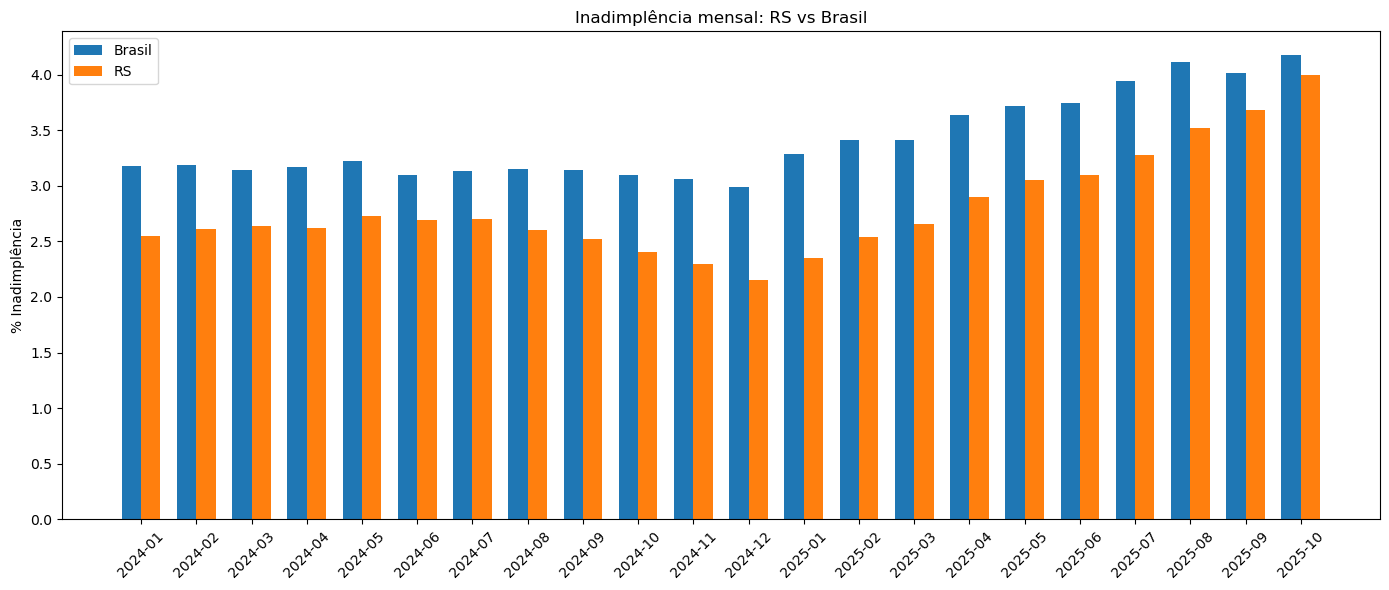

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar dados
df_plot = base_mensal[['data_base', 'regiao', 'pct_inadimplencia']].copy()

# Pivotar para formato largo (uma coluna para RS e outra para BR)
df_pivot = df_plot.pivot(index='data_base', columns='regiao', values='pct_inadimplencia')

# Posições no eixo x
x = np.arange(len(df_pivot.index))
largura = 0.35

# Criar gráfico
plt.figure(figsize=(14, 6))
plt.bar(x - largura/2, df_pivot['BR'], largura, label='Brasil')
plt.bar(x + largura/2, df_pivot['RS'], largura, label='RS')

# Ajustes do gráfico
plt.xticks(x, df_pivot.index.strftime('%Y-%m'), rotation=45)
plt.ylabel('% Inadimplência')
plt.title('Inadimplência mensal: RS vs Brasil')
plt.legend()
plt.tight_layout()

plt.show()


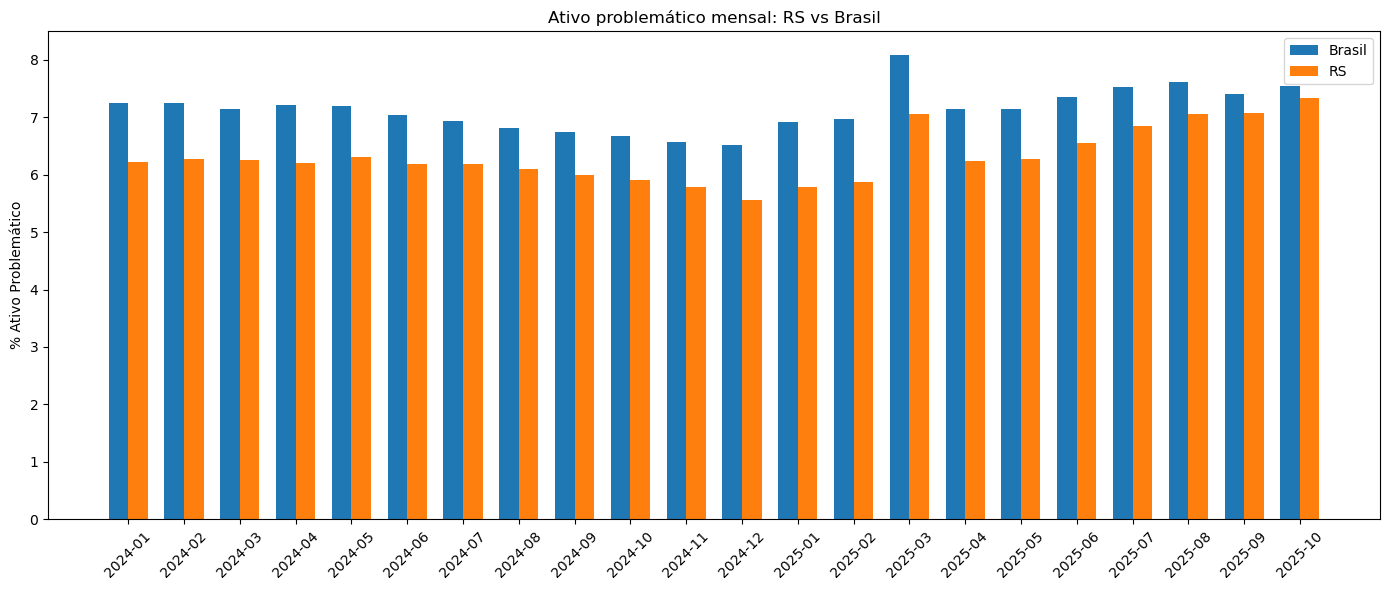

In [51]:
# Preparar dados
df_plot = base_mensal[['data_base', 'regiao', 'pct_ativo_problematico']].copy()

# Pivotar para formato largo
df_pivot = df_plot.pivot(index='data_base', columns='regiao', values='pct_ativo_problematico')

# Posições no eixo x
x = np.arange(len(df_pivot.index))
largura = 0.35

# Criar gráfico
plt.figure(figsize=(14, 6))
plt.bar(x - largura/2, df_pivot['BR'], largura, label='Brasil')
plt.bar(x + largura/2, df_pivot['RS'], largura, label='RS')

# Ajustes
plt.xticks(x, df_pivot.index.strftime('%Y-%m'), rotation=45)
plt.ylabel('% Ativo Problemático')
plt.title('Ativo problemático mensal: RS vs Brasil')
plt.legend()
plt.tight_layout()

plt.show()

2. Existe associação entre o percentual de ativos problemáticos e o percentual de inadimplência ao longo do tempo?<br>
O seguinte gráfico de dispensão apresenta a relação entre o ativo problemático e a inadimplência e é possível observar que existe uma tendência positiva ao olharmos para o RS, enquanto que a nível nacional, essa tendência existe, mas não tão homogênea. Talvez uma causa possível para essa diferença, seja que o agregado nacional sofre influência da realidade de cada federação, o que aumenta a possíbilidade de comportamentos menos homogêneos.
Essa dúvida seria sanada se fosse realizada uma análise de cada federação. 

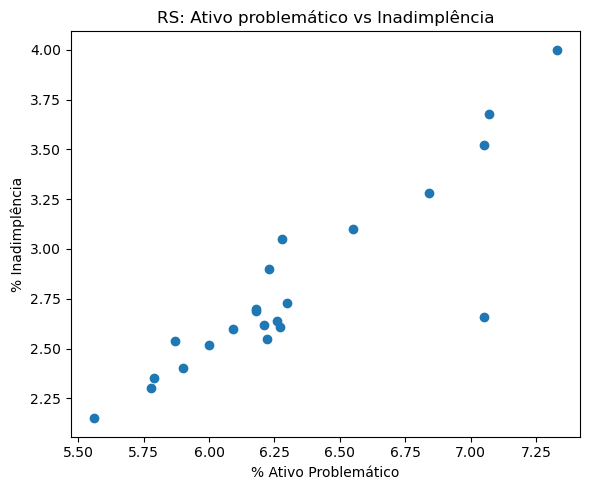

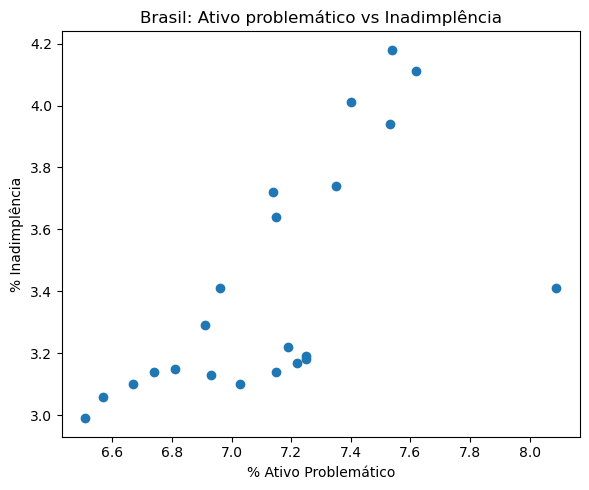

In [53]:
import matplotlib.pyplot as plt

# --- RS ---
df_rs = base_mensal[base_mensal['regiao'] == 'RS']

plt.figure(figsize=(6, 5))
plt.scatter(
    df_rs['pct_ativo_problematico'],
    df_rs['pct_inadimplencia']
)
plt.xlabel('% Ativo Problemático')
plt.ylabel('% Inadimplência')
plt.title('RS: Ativo problemático vs Inadimplência')
plt.tight_layout()
plt.show()


# --- Brasil ---
df_br = base_mensal[base_mensal['regiao'] == 'BR']

plt.figure(figsize=(6, 5))
plt.scatter(
    df_br['pct_ativo_problematico'],
    df_br['pct_inadimplencia']
)
plt.xlabel('% Ativo Problemático')
plt.ylabel('% Inadimplência')
plt.title('Brasil: Ativo problemático vs Inadimplência')
plt.tight_layout()
plt.show()


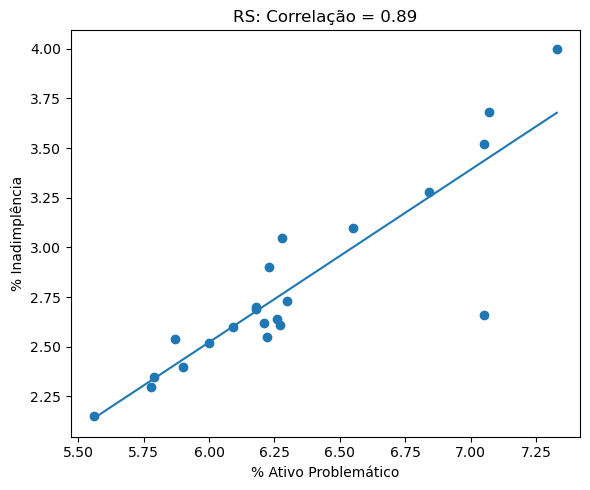

np.float64(0.886229348325751)

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar RS
df_rs = base_mensal[base_mensal['regiao'] == 'RS']

# Calcular correlação
corr_rs = df_rs['pct_ativo_problematico'].corr(df_rs['pct_inadimplencia'])

# Ajuste linear (reta)
coef = np.polyfit(
    df_rs['pct_ativo_problematico'],
    df_rs['pct_inadimplencia'],
    1
)

x_vals = np.linspace(
    df_rs['pct_ativo_problematico'].min(),
    df_rs['pct_ativo_problematico'].max(),
    100
)

y_vals = coef[0] * x_vals + coef[1]

# Gráfico
plt.figure(figsize=(6, 5))
plt.scatter(
    df_rs['pct_ativo_problematico'],
    df_rs['pct_inadimplencia']
)
plt.plot(x_vals, y_vals)
plt.xlabel('% Ativo Problemático')
plt.ylabel('% Inadimplência')
plt.title(f'RS: Correlação = {corr_rs:.2f}')
plt.tight_layout()
plt.show()

corr_rs


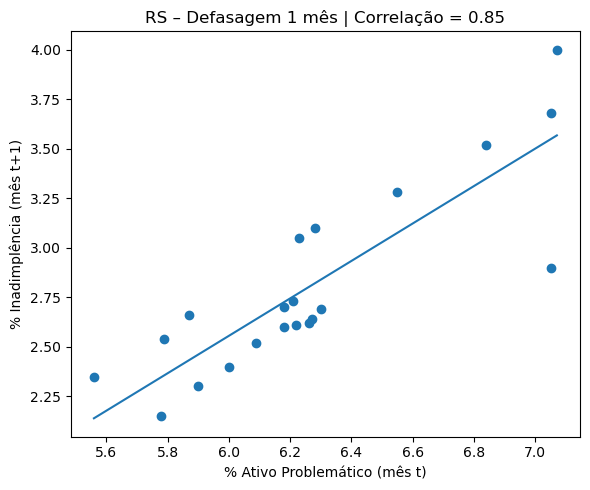

np.float64(0.8546648041664294)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Filtrar RS e ordenar no tempo
df_rs = (base_mensal[base_mensal['regiao'] == 'RS'].sort_values('data_base').copy())

# Criar defasagem: inadimplência no mês seguinte
df_rs['pct_inadimplencia_t1'] = df_rs['pct_inadimplencia'].shift(-1)

# Remover último mês (fica sem t+1)
df_rs_def = df_rs.dropna(subset=['pct_inadimplencia_t1'])

# Correlação defasada
corr_defasada = df_rs_def['pct_ativo_problematico'].corr(df_rs_def['pct_inadimplencia_t1'])

# Ajuste linear
coef = np.polyfit(df_rs_def['pct_ativo_problematico'], df_rs_def['pct_inadimplencia_t1'], 1)

x_vals = np.linspace(
    df_rs_def['pct_ativo_problematico'].min(),
    df_rs_def['pct_ativo_problematico'].max(),
    100
)
y_vals = coef[0] * x_vals + coef[1]

# Gráfico
plt.figure(figsize=(6, 5))
plt.scatter(
    df_rs_def['pct_ativo_problematico'],
    df_rs_def['pct_inadimplencia_t1']
)
plt.plot(x_vals, y_vals)
plt.xlabel('% Ativo Problemático (mês t)')
plt.ylabel('% Inadimplência (mês t+1)')
plt.title(f'RS – Defasagem 1 mês | Correlação = {corr_defasada:.2f}')
plt.tight_layout()
plt.show()

corr_defasada


Dado que o ativo problemático representa um indicador de risco latente, explorou-se também sua relação com a inadimplência em períodos subsequentes. Para isso, avaliou-se a associação entre o percentual de ativo problemático em um determinado mês e o percentual de inadimplência no mês seguinte, de forma exploratória.

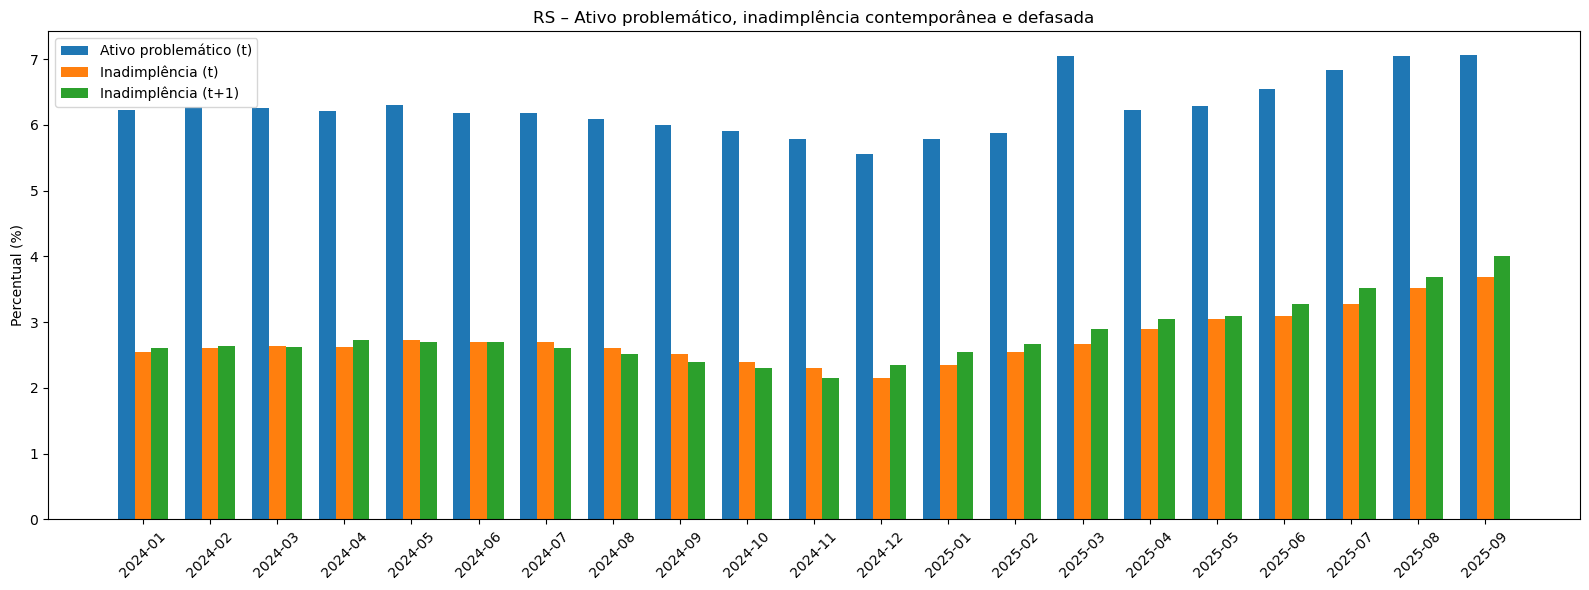

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar RS e ordenar
df_rs = (
    base_mensal[base_mensal['regiao'] == 'RS']
    .sort_values('data_base')
    .copy()
)

# Criar inadimplência defasada (t+1)
df_rs['pct_inadimplencia_t1'] = df_rs['pct_inadimplencia'].shift(-1)

# Remover último mês (não tem t+1)
df_plot = df_rs.dropna(subset=['pct_inadimplencia_t1'])

# Eixo x
x = np.arange(len(df_plot))
largura = 0.25

# Gráfico
plt.figure(figsize=(16, 6))
plt.bar(
    x - largura,
    df_plot['pct_ativo_problematico'],
    largura,
    label='Ativo problemático (t)'
)
plt.bar(
    x,
    df_plot['pct_inadimplencia'],
    largura,
    label='Inadimplência (t)'
)
plt.bar(
    x + largura,
    df_plot['pct_inadimplencia_t1'],
    largura,
    label='Inadimplência (t+1)'
)

# Ajustes
plt.xticks(x, df_plot['data_base'].dt.strftime('%Y-%m'), rotation=45)
plt.ylabel('Percentual (%)')
plt.title('RS – Ativo problemático, inadimplência contemporânea e defasada')
plt.legend()
plt.tight_layout()

plt.show()


A comparação entre as relações contemporânea e defasada revela que o ativo problemático possui maior poder explicativo para a inadimplência observada no mesmo período do que para a inadimplência futura. Embora a associação defasada permaneça positiva, sua menor intensidade e maior dispersão indicam que o indicador atua predominantemente como um termômetro do risco corrente, e não como um instrumento de predição isolada da inadimplência.

Conclusão

Esta análise teve como objetivo investigar a dinâmica do risco de crédito no Rio Grande do Sul a partir dos dados agregados do Sistema de Informações de Crédito (SCR), utilizando o agregado nacional como benchmark. A partir da construção de indicadores percentuais baseados na carteira ativa, foi possível comparar a evolução da inadimplência e do ativo problemático ao longo do período de janeiro de 2024 a outubro de 2025.

Os resultados indicam que o Rio Grande do Sul apresentou, de forma consistente, níveis de inadimplência inferiores aos observados no agregado nacional, embora acompanhe as oscilações gerais do ciclo de crédito, sugerindo a influência de fatores macroeconômicos comuns. A análise descritiva evidenciou uma forte associação contemporânea entre o percentual de ativo problemático e o percentual de inadimplência, indicando que ambos refletem, no mesmo período, o estado de saúde da carteira de crédito.

Ao introduzir uma defasagem temporal de um mês, observou-se que a relação entre o ativo problemático e a inadimplência futura permanece positiva, porém com menor intensidade e maior dispersão. Esse resultado sugere que o ativo problemático não atua como um preditor determinístico da inadimplência, mas sim como um indicador de risco latente, capturando sinais de fragilidade e estresse da carteira antes da plena materialização dos eventos de inadimplência. A ausência de convergência plena entre os indicadores reforça o papel do ativo problemático como um termômetro contemporâneo da qualidade do crédito, mais do que como um instrumento de previsão isolada.

Optou-se por não empregar modelos preditivos formais nesta análise por três razões principais. Em primeiro lugar, a série temporal disponível é relativamente curta para a estimação robusta de modelos de previsão, o que poderia levar a resultados instáveis ou superajustados. Em segundo lugar, os dados analisados são altamente agregados, o que limita a identificação de relações causais e reduz a eficácia de abordagens preditivas baseadas apenas em médias ou percentuais agregados. Por fim, o objetivo central do estudo foi compreender a relação econômica e temporal entre os indicadores de risco, e não realizar previsões operacionais, o que justifica a priorização de uma análise exploratória rigorosa, interpretável e alinhada às limitações dos dados.

Conclui-se, portanto, que o ativo problemático constitui um indicador relevante para o monitoramento prudencial e a gestão de risco da carteira de crédito, ao refletir o grau de fragilidade financeira presente no sistema em determinado momento. Análises futuras poderiam aprofundar essa investigação por meio da desagregação por unidade federativa ou da incorporação de séries mais longas, a fim de avaliar a robustez das relações observadas em diferentes contextos regionais e temporais.